Doing analysis on the data before visualizing it in D3 - all analysis is on the fatal Pedestrian crashes that occurred in CABQ between 2012-2023

In [34]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# Paths (.. means “one folder up” from your notebook)
root = Path.cwd()                      # wherever your notebook is
gj_path = root.parent / "ped_fatalities_20250911_1343.geojson"   # one level up
gpkg_path = "ped_crashes_SVIJoin_100ft.gpkg"    # your enriched file

# Read the geojson that drives the map (keep geometry & CRS as-is, likely EPSG:4326)
gj = gpd.read_file(gj_path)

# Read the enriched crashes from the GPKG, but drop its geometry so we don't have 2 geometries
enriched = gpd.read_file(gpkg_path)
attr = pd.DataFrame(enriched.drop(columns=enriched.geometry.name))  # purely tabular

attr.head()


,UCRnumber,CRASH DATE,MONTH,TIME OF CRASH,HOUR OF CRASH,DAY OF WEEK,CRASH SEVERITY,NUMBER OF PEOPLE KILLED IN CRASH,NUMBER OF PEOPLE WITH INCAPACITATING INJURIES (CLASS A) IN CRASH,NUMBER OF PEOPLE WITH VISIBLE INJURIES (CLASS B) IN CRASH,...,YEAR,CRASH_YEAR,SPL_THEMES_count,SPL_THEMES_min,SPL_THEMES_max,SPL_THEMES_mean,RPL_THEMES_count,RPL_THEMES_min,RPL_THEMES_max,RPL_THEMES_mean
0,131931117,7/12/2013,July,17:22,5 p.m.,Friday,Fatal Crash,1,0,0,...,2013,2013,2,5.7902,10.2160,8.0031,2,0.2000,0.8783,0.53915
1,30097966,12/16/2012,December,5:06,5 a.m.,Sunday,Fatal Crash,1,0,0,...,2012,2012,2,8.1999,10.2903,9.2451,2,0.5700,0.8867,0.72835
2,30143912,5/29/2017,May,23:58,11 p.m.,Monday,Fatal Crash,1,0,0,...,2017,2017,2,8.0584,11.3594,9.7089,2,0.5483,0.9717,0.76000
3,30177308,2/9/2016,February,22:19,10 p.m.,Tuesday,Fatal Crash,1,0,0,...,2016,2016,1,10.2676,10.2676,10.2676,1,0.8817,0.8817,0.88170
4,30350965,4/9/2023,April,20:18,8 p.m.,Sunday,Fatal Crash,1,0,0,...,2023,2023,1,4.8076,4.8076,4.8076,1,0.0983,0.0983,0.09830


In [35]:
# Sanity checks (optional but recommended)
key = "UCRnumber"                         # <- replace with your actual key field
assert key in gj.columns and key in attr.columns, "Key missing!"
dup_keys = attr[key][attr.duplicated(key)]
assert dup_keys.empty, f"Duplicate keys in enriched: {dup_keys.unique()[:5]}"

# Merge attributes onto the geojson features
merged = gj.merge(
    attr[[key, "RPL_THEMES_max", "RPL_THEMES_mean", "RPL_THEMES_count"]],  # adjust field names
    on=key, how="left", validate="one_to_one"
)

# Nice-to-have fields for popups / charts
merged["SVI_ge_0_8"] = (merged["RPL_THEMES_max"] >= 0.8).fillna(False)
merged["SVI_max"] = merged["RPL_THEMES_max"].round(3)
merged["SVI_mean"] = merged["RPL_THEMES_mean"].round(3)

# Write a new GeoJSON the map can load (still in WGS84)
# out_path = root.parent / "ped_fatalities_enriched.geojson"
# merged.to_file(out_path, driver="GeoJSON")
# print("Wrote:", out_path)

   YEAR  prop_highSVI  total_crashes
0  2012      0.437500             16
1  2013      0.352941             17
2  2014      0.464286             28
3  2015      0.461538             13
4  2016      0.464286             28


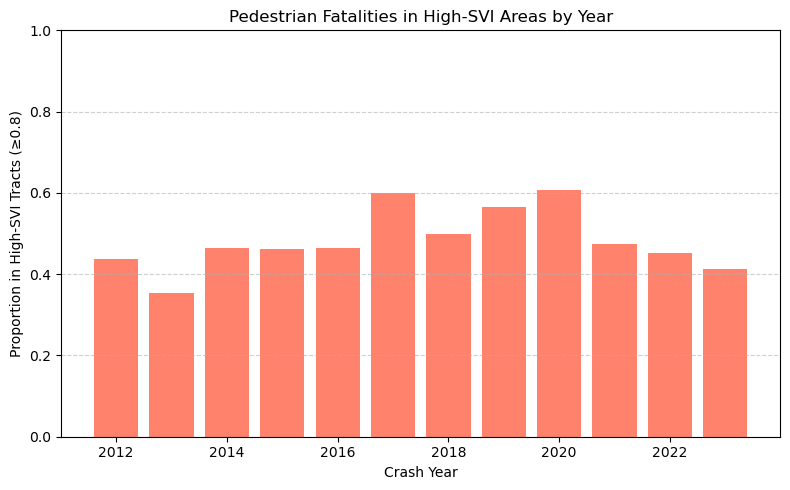

In [4]:
import matplotlib.pyplot as plt

# Make sure your crash year field exists; adjust if it’s named differently
year_col = "YEAR"      # or e.g. "CrashYear", "CRASH_DATE". If date, extract year first:
# merged["YEAR"] = pd.to_datetime(merged["CRASH_DATE"]).dt.year

# Calculate counts and proportions
summary = (
    merged
    .groupby(year_col)["SVI_ge_0_8"]
    .agg(['mean','count'])
    .rename(columns={'mean':'prop_highSVI','count':'total_crashes'})
    .reset_index()
)

print(summary.head())   # quick check

# Plot
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(summary[year_col], summary['prop_highSVI'], color='tomato', alpha=0.8)

ax.set_xlabel("Crash Year")
ax.set_ylabel("Proportion in High-SVI Tracts (≥0.8)")
ax.set_title("Pedestrian Fatalities in High-SVI Areas by Year")
ax.set_ylim(0,1)        # because proportion
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [5]:
merged.columns

Index(['UCRnumber', 'CRASH DATE', 'MONTH', 'TIME OF CRASH', 'HOUR OF CRASH',
       'DAY OF WEEK', 'CRASH SEVERITY', 'NUMBER OF PEOPLE KILLED IN CRASH',
       'NUMBER OF PEOPLE WITH INCAPACITATING INJURIES (CLASS A) IN CRASH',
       'NUMBER OF PEOPLE WITH VISIBLE INJURIES (CLASS B) IN CRASH',
       'NUMBER OF PEOPLE WITH POSSIBLE INJURIES (CLASS C) IN CRASH',
       'NUMBER OF PEOPLE INJURED (CLASS A+B+C) IN CRASH',
       'NUMBER OF PEOPLE NOT INJURED (CLASS O) IN CRASH',
       'TOTAL NUMBER OF PEOPLE IN CRASH',
       'NUMBER OF VEHICLES, BICYCLES, AND PEDESTRIANS INVOLVED',
       'NUMBER OF PEOPLE IN MOTOR VEHICLES',
       'NUMBER OF PEOPLE NOT IN MOTOR VEHICLES',
       'NUMBER OF MOTOR VEHICLES INVOLVED', 'FIRST HARMFUL EVENT OCCURRED',
       'CRASH CLASSIFICATION', 'CRASH ANALYSIS', 'FIRST HARMFUL EVENT',
       'FIRST HARMFUL EVENT - ANALYSIS', 'FIRST HARMFUL EVENT  LOCATION',
       'FIRST HARMFUL EVENT  MANNER OF IMPACT',
       'FIRST HARMFUL EVENT  MANNER OF CRASH'

In [8]:
merged["LIGHTING"].unique()

array(['Daylight', 'Dark-Lighted', 'Dark-Not Lighted', 'Invalid Code',
       'Left Blank', 'Dawn', 'Dusk', 'Dark-Unknown Lighting'],
      dtype=object)

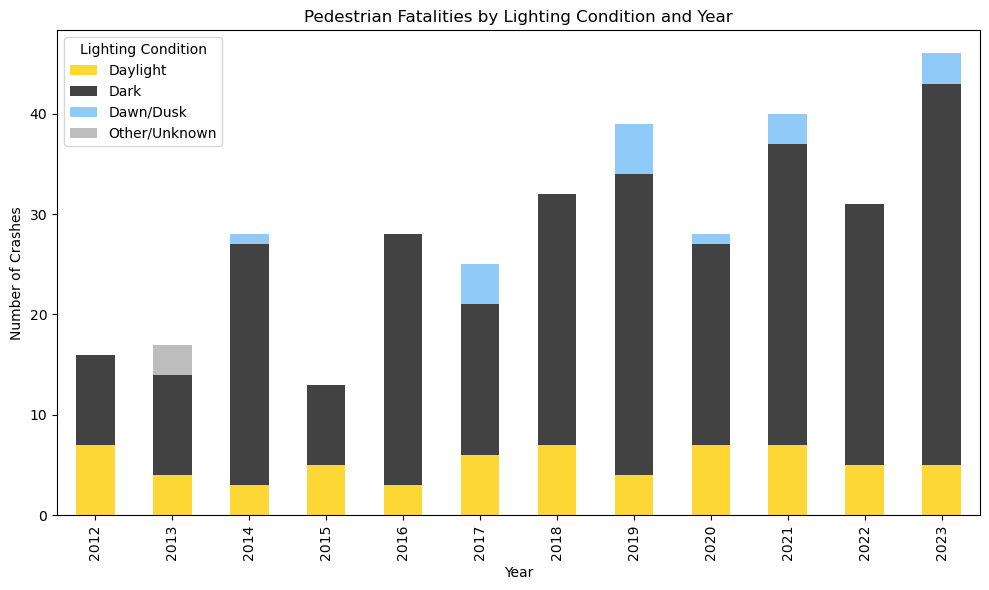

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define mapping dictionary
lighting_map = {
    'Daylight': 'Daylight',
    'Dark-Lighted': 'Dark',
    'Dark-Not Lighted': 'Dark',
    'Dark-Unknown Lighting': 'Dark',
    'Dawn': 'Dawn/Dusk',
    'Dusk': 'Dawn/Dusk',
    'Invalid Code': 'Other/Unknown',
    'Left Blank': 'Other/Unknown'
}

# Apply mapping
merged["Lighting_Cat"] = merged["LIGHTING"].map(lighting_map)

# Group by year and lighting category
year_col = "YEAR"  # adjust if needed
lighting_summary = (
    merged.groupby([year_col, "Lighting_Cat"])
          .size()
          .unstack(fill_value=0)
)

# Optional: sort columns so Daylight and Dark are first
lighting_summary = lighting_summary[["Daylight", "Dark", "Dawn/Dusk", "Other/Unknown"]]

# Plot stacked bar
fig, ax = plt.subplots(figsize=(10,6))
lighting_summary.plot(
    kind="bar", stacked=True,
    color=["#fdd835","#424242","#90caf9","#bdbdbd"],
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Crashes")
ax.set_title("Pedestrian Fatalities by Lighting Condition and Year")
ax.legend(title="Lighting Condition")
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd
import numpy as np

# `lighting_summary` already has counts per year × lighting category
# Add a 'Total' column for convenience
lighting_counts = lighting_summary.copy()
lighting_counts["Total"] = lighting_counts.sum(axis=1)

# Compute percentages for each category (row-wise)
lighting_pct = (
    lighting_summary
    .div(lighting_summary.sum(axis=1), axis=0)   # divide each row by its total
    .round(3) * 100                              # convert to %
)
lighting_pct["Total"] = 100.0                    # total is always 100%

# If you want overall totals (all years combined)
overall_counts = lighting_counts.sum(axis=0).to_frame(name="Count")
overall_pct = (
    (overall_counts["Count"] / overall_counts.loc["Total","Count"])
    .round(3) * 100
)
overall_summary = pd.concat([overall_counts, overall_pct.rename("Percent")], axis=1)

# Display nicely
print("---- Yearly Counts ----")
print(lighting_counts)

print("\n---- Yearly Percentages ----")
print(lighting_pct)

print("\n---- Overall Totals ----")
print(overall_summary)


---- Yearly Counts ----
Lighting_Cat  Daylight  Dark  Dawn/Dusk  Other/Unknown  Total
YEAR                                                         
2012                 7     9          0              0     16
2013                 4    10          0              3     17
2014                 3    24          1              0     28
2015                 5     8          0              0     13
2016                 3    25          0              0     28
2017                 6    15          4              0     25
2018                 7    25          0              0     32
2019                 4    30          5              0     39
2020                 7    20          1              0     28
2021                 7    30          3              0     40
2022                 5    26          0              0     31
2023                 5    38          3              0     46

---- Yearly Percentages ----
Lighting_Cat  Daylight  Dark  Dawn/Dusk  Other/Unknown  Total
YEAR            

In [12]:
merged['HIT AND RUN CRASH'].unique()

array(['No', 'Yes', 'Left Blank'], dtype=object)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

year_col = "YEAR"    # adjust if needed
field = "HIT AND RUN CRASH"

# Clean / collapse categories
hitrun_map = {
    'Yes': 'Hit & Run',
    'No': 'Not Hit & Run',
    'Left Blank': 'Unknown'
}
merged["HitRun_Cat"] = merged[field].map(hitrun_map)

# Group by year and category
hitrun_summary = (
    merged.groupby([year_col, "HitRun_Cat"])
          .size()
          .unstack(fill_value=0)
)

# Add totals
hitrun_summary["Total"] = hitrun_summary.sum(axis=1)

# Percentages
hitrun_pct = (
    hitrun_summary
    .div(hitrun_summary["Total"], axis=0)
    .round(3) * 100
)

print("---- Yearly Counts ----")
print(hitrun_summary)
print("\n---- Yearly Percentages ----")
print(hitrun_pct)


---- Yearly Counts ----
HitRun_Cat  Hit & Run  Not Hit & Run  Unknown  Total
YEAR                                                
2012                2             14        0     16
2013                2             14        1     17
2014                9             19        0     28
2015                3             10        0     13
2016               10             18        0     28
2017                4             21        0     25
2018                7             25        0     32
2019               14             25        0     39
2020               10             18        0     28
2021               19             21        0     40
2022               10             21        0     31
2023               17             29        0     46

---- Yearly Percentages ----
HitRun_Cat  Hit & Run  Not Hit & Run  Unknown  Total
YEAR                                                
2012             12.5           87.5      0.0  100.0
2013             11.8           82.4      5.9

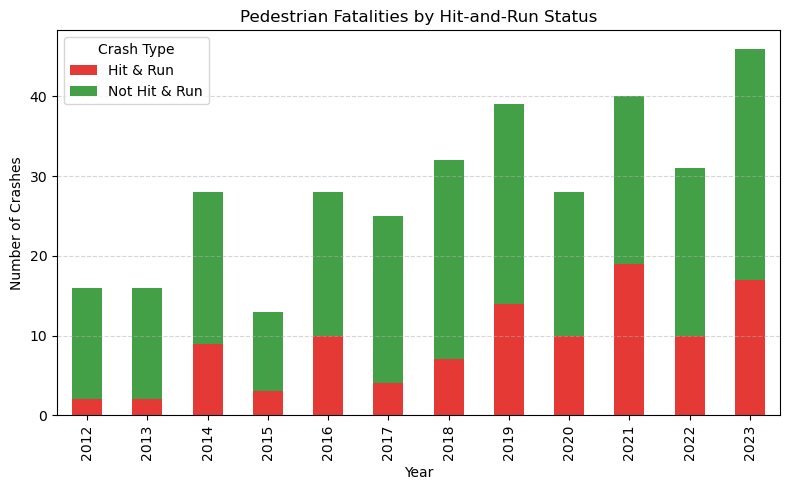

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
hitrun_summary[["Hit & Run","Not Hit & Run"]].plot(
    kind="bar", stacked=True,
    color=["#e53935","#43a047"],
    ax=ax
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Crashes")
ax.set_title("Pedestrian Fatalities by Hit-and-Run Status")
ax.legend(title="Crash Type")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


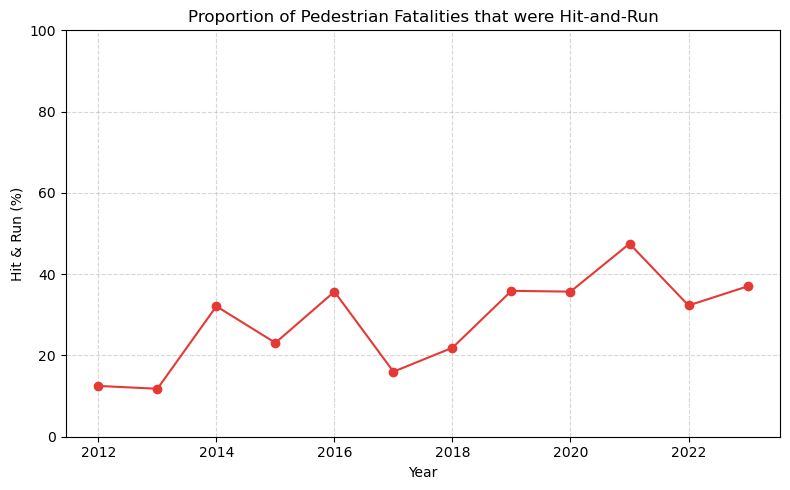

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(hitrun_pct.index, hitrun_pct["Hit & Run"], marker='o', color="#e53935")
ax.set_xlabel("Year")
ax.set_ylabel("Hit & Run (%)")
ax.set_title("Proportion of Pedestrian Fatalities that were Hit-and-Run")
ax.set_ylim(0,100)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
merged['ALCOHOL INVOLVEMENT'].unique()

array(['Not Involved', 'Involved'], dtype=object)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

year_col = "YEAR"
alc = "ALCOHOL INVOLVEMENT"
drug = "DRUG INVOLVEMENT"

def combo(row):
    a, d = row[alc], row[drug]
    if a == "Involved" and d == "Involved":
        return "Both"
    elif a == "Involved":
        return "Alcohol Only"
    elif d == "Involved":
        return "Drug Only"
    else:
        return "Neither"

merged["Substance_Cat"] = merged.apply(combo, axis=1)


In [18]:
sub_summary = (
    merged.groupby([year_col, "Substance_Cat"])
          .size()
          .unstack(fill_value=0)
)

# Add totals
sub_summary["Total"] = sub_summary.sum(axis=1)

# Percentages
sub_pct = (
    sub_summary
    .div(sub_summary["Total"], axis=0)
    .round(3) * 100
)

print("---- Yearly Counts ----")
print(sub_summary)
print("\n---- Yearly Percentages ----")
print(sub_pct)


---- Yearly Counts ----
Substance_Cat  Alcohol Only  Both  Drug Only  Neither  Total
YEAR                                                        
2012                      9     1          0        6     16
2013                     10     0          1        6     17
2014                     13     2          0       13     28
2015                      6     0          3        4     13
2016                     15     4          0        9     28
2017                     10     2          2       11     25
2018                      6    10          7        9     32
2019                     13    11          3       12     39
2020                      7     3          9        9     28
2021                      2     7         12       19     40
2022                      1    11         11        8     31
2023                      8    14         13       11     46

---- Yearly Percentages ----
Substance_Cat  Alcohol Only  Both  Drug Only  Neither  Total
YEAR                           

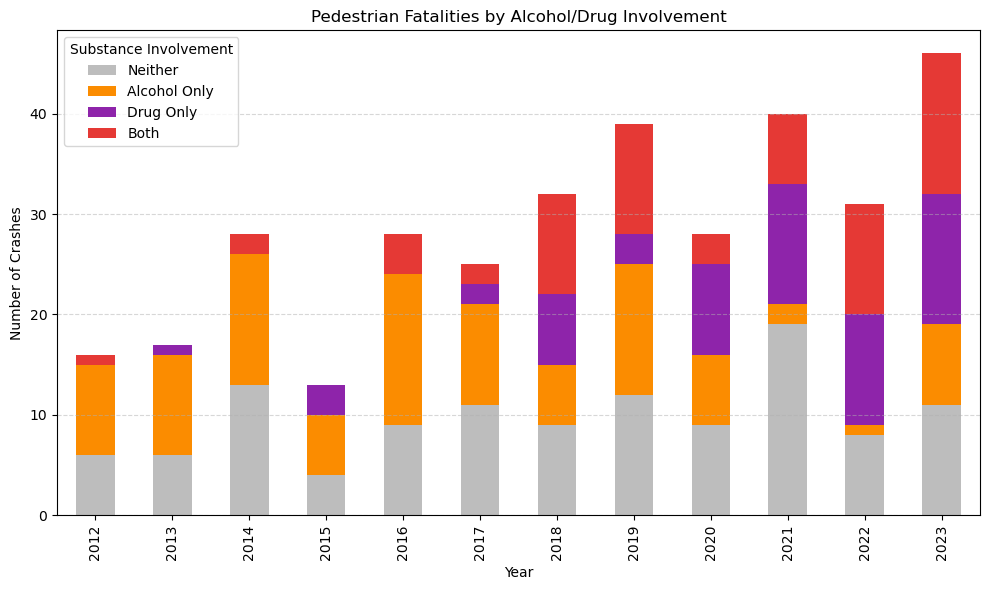

In [19]:
# Order columns for consistent coloring
cols = ["Neither","Alcohol Only","Drug Only","Both"]
sub_summary = sub_summary[cols + ["Total"]]  # reorder for plotting

fig, ax = plt.subplots(figsize=(10,6))
sub_summary[cols].plot(
    kind="bar", stacked=True,
    color=["#bdbdbd","#fb8c00","#8e24aa","#e53935"],
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Crashes")
ax.set_title("Pedestrian Fatalities by Alcohol/Drug Involvement")
ax.legend(title="Substance Involvement")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [1]:
import geopandas as gpd
import fiona

path = "ped_crashes.gpkg"

# See what's inside
layers = fiona.listlayers(path)
print(layers)  # e.g. ['ped_fatal6526', 'ped_injury', 'network_links', ...]




['ped_all_6529', 'ped_fatal_6529']


In [4]:
# Load a specific layer by name
ped_fatal_enriched = gpd.read_file(path, layer="ped_fatal_6529")
ped_fatal_enriched.shape

(344, 84)

In [5]:
ped_fatal_enriched.head()

,UCRnumber,CRASH DATE,Year,MONTH,TIME OF CRASH,HOUR OF CRASH,DAY OF WEEK,LAW ENFORCEMENT AGENCY,COUNTY,CITY,...,ORIGINAL LONGITUDE,ORIGINAL UCR NUMBER,CASE NUMBER,STATION REPORT,TRACS DATA,Interstate,Intersection,Facility,LANES,geometry
0,131931117,7/12/2013,2013,July,17:22,5 p.m.,Friday,Albuquerque Police Department,Bernalillo,Albuquerque,...,None,None,130062441,No,No,1.0,0,Interstate,3.0,POINT (1526944.264 1493776.793)
1,30097966,12/16/2012,2012,December,5:06,5 a.m.,Sunday,Bernalillo County Sheriffs Department,Bernalillo,None,...,None,None,12682478,No,No,1.0,0,Interstate,3.0,POINT (1524368.591 1483834.461)
2,30143912,5/29/2017,2017,May,23:58,11 p.m.,Monday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,None,9999920,17 - 660913,No,No,NaN,0,4,4.0,POINT (1500953.999 1461110.225)
3,30177308,2/9/2016,2016,February,22:19,10 p.m.,Tuesday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,None,None,16-616310,No,No,1.0,0,Interstate,2.0,POINT (1520887.487 1451568.463)
4,30350965,4/9/2023,2023,April,20:18,8 p.m.,Sunday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,None,None,SO23040004808,No,No,NaN,0,2,2.0,POINT (1500257.647 1479187.887)


In [7]:
by_year = (
    ped_fatal_enriched
    .groupby("Year")
    .agg(
        total_crashes = ("UCRnumber", "count"),
        interstate    = ("Interstate", "sum")
    )
)
by_year["pct_interstate"] = (
    by_year["interstate"] / by_year["total_crashes"] * 100
)
print(by_year)

      total_crashes  interstate  pct_interstate
Year                                           
2012             17         1.0        5.882353
2013             17         3.0       17.647059
2014             28         3.0       10.714286
2015             13         3.0       23.076923
2016             28         4.0       14.285714
2017             25         0.0        0.000000
2018             32         2.0        6.250000
2019             39         3.0        7.692308
2020             28         8.0       28.571429
2021             40         5.0       12.500000
2022             31         5.0       16.129032
2023             46        14.0       30.434783


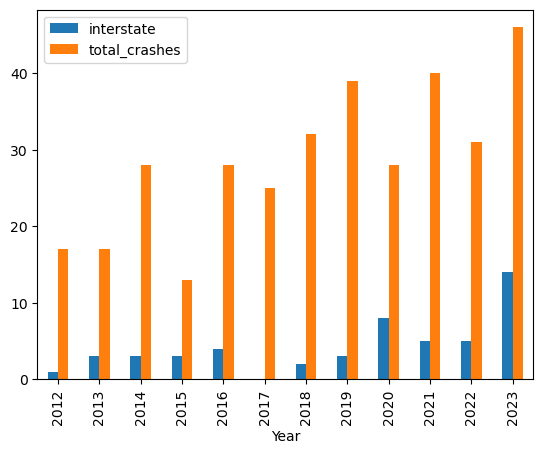

In [8]:
import matplotlib.pyplot as plt

by_year[["interstate", "total_crashes"]].plot(kind="bar")
plt.show()


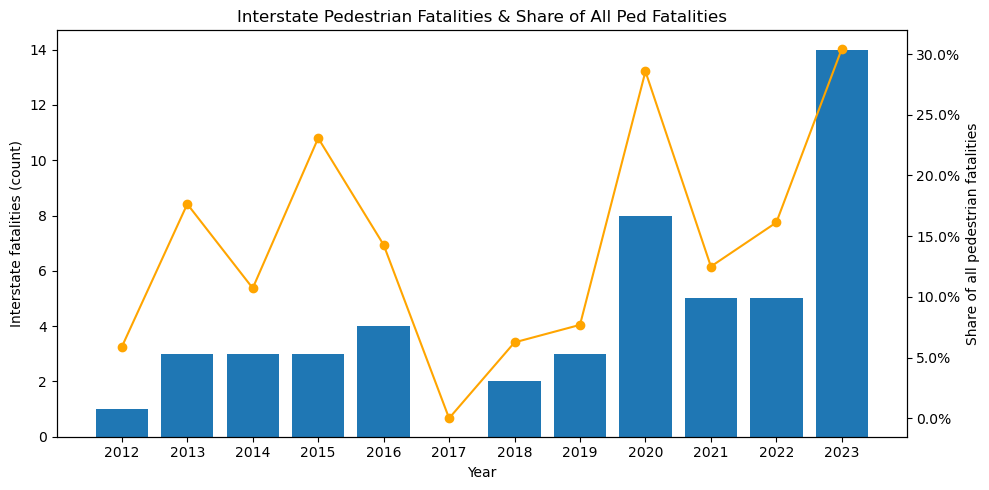

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Make sure it's sorted by year and counts are ints (optional)
by_year = by_year.sort_index().copy()
by_year["interstate"] = by_year["interstate"].astype(int)

fig, ax1 = plt.subplots(figsize=(10,5))

# Bars: interstate fatal counts
bars = ax1.bar(by_year.index, by_year["interstate"])
ax1.set_xlabel("Year")
ax1.set_ylabel("Interstate fatalities (count)")
ax1.set_title("Interstate Pedestrian Fatalities & Share of All Ped Fatalities")

# Line (secondary axis): percent of all crashes
ax2 = ax1.twinx()
line = ax2.plot(by_year.index, by_year["pct_interstate"], marker="o", color="orange")
ax2.set_ylabel("Share of all pedestrian fatalities")
ax2.yaxis.set_major_formatter(PercentFormatter())  # show as %

# Optional: make x-ticks show as integers
ax1.set_xticks(by_year.index)

plt.tight_layout()
plt.show()


In [12]:
ped_fatal_enriched["Facility"].unique()

array(['Interstate', '4', '2', 'Intersection', '6', 'OFF NETWORK', '3',
       '5', '8'], dtype=object)

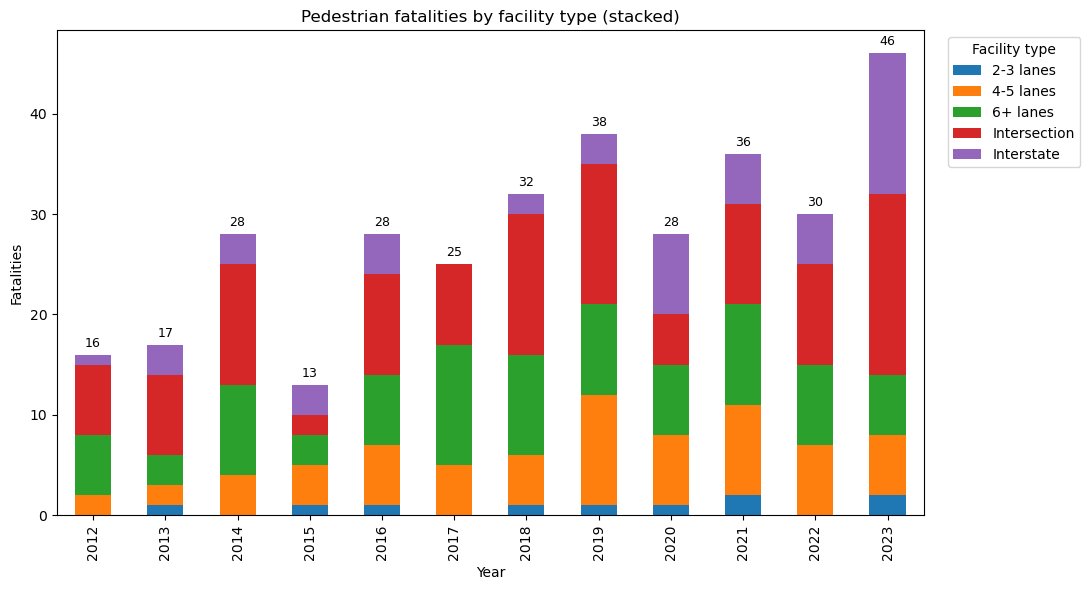

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = ped_fatal_enriched.copy()

# 1) Drop OFF NETWORK (only 7 total per your note)
df = df[~df["Facility"].fillna("").str.upper().eq("OFF NETWORK")].copy()

# 2) Bucket facility types:
#    - keep "Interstate" and "Intersection"
#    - group lanes: 2–3, 4–5, 6+ (handles strings or numbers)
def bucket_fac(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    if s.lower() in ("interstate", "intersection"):
        return s.capitalize()
    try:
        n = int(float(s))  # works for '2','3','4','5','6','7','8'
    except ValueError:
        return None
    if n >= 6:
        return "6+ lanes"
    elif n >= 4:
        return "4-5 lanes"
    elif n >= 2:
        return "2-3 lanes"
    else:
        return None

df["Facility_group"] = df["Facility"].apply(bucket_fac)
df = df[df["Facility_group"].notna()].copy()

# 3) Pivot: counts per Year x Facility_group
pivot = (
    df.groupby(["Year", "Facility_group"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

# Optional: order the stacked categories
order = [c for c in ["2-3 lanes","4-5 lanes","6+ lanes","Intersection","Interstate"]
         if c in pivot.columns]
pivot = pivot.reindex(columns=order)

# 4) Plot: stacked bar
ax = pivot.plot(kind="bar", stacked=True, figsize=(11,6))
ax.set_title("Pedestrian fatalities by facility type (stacked)")
ax.set_xlabel("Year")
ax.set_ylabel("Fatalities")
ax.legend(title="Facility type", bbox_to_anchor=(1.02, 1), loc="upper left")

# Optional: annotate totals on top of each bar
totals = pivot.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 0.5, int(total), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


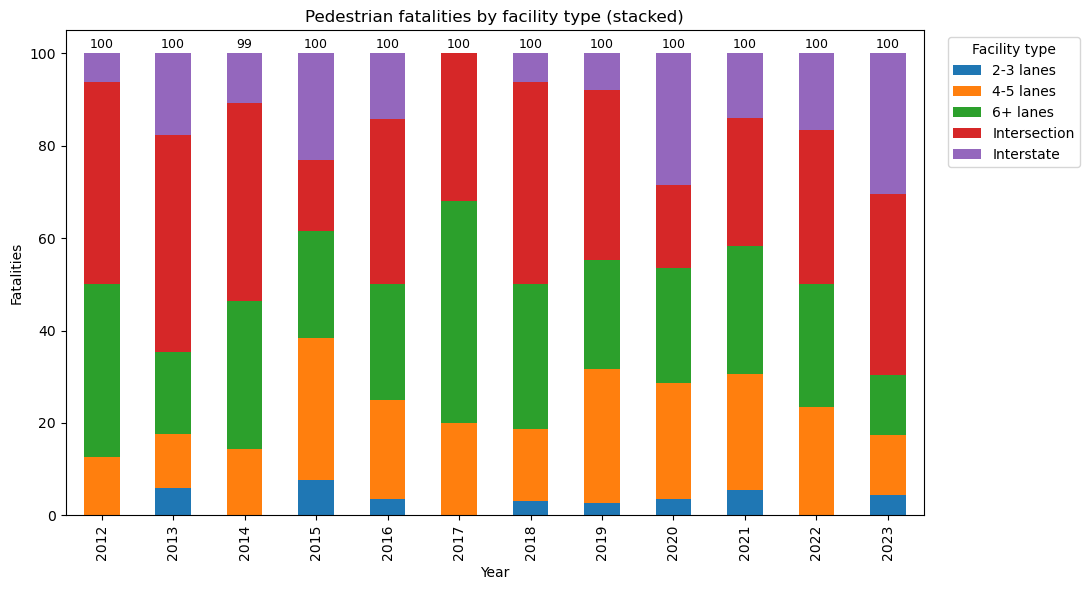

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = ped_fatal_enriched.copy()

# 1) Drop OFF NETWORK (only 7 total per your note)
df = df[~df["Facility"].fillna("").str.upper().eq("OFF NETWORK")].copy()

# 2) Bucket facility types:
#    - keep "Interstate" and "Intersection"
#    - group lanes: 2–3, 4–5, 6+ (handles strings or numbers)
def bucket_fac(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    if s.lower() in ("interstate", "intersection"):
        return s.capitalize()
    try:
        n = int(float(s))  # works for '2','3','4','5','6','7','8'
    except ValueError:
        return None
    if n >= 6:
        return "6+ lanes"
    elif n >= 4:
        return "4-5 lanes"
    elif n >= 2:
        return "2-3 lanes"
    else:
        return None

df["Facility_group"] = df["Facility"].apply(bucket_fac)
df = df[df["Facility_group"].notna()].copy()

# 3) Pivot: counts per Year x Facility_group
pivot = (
    df.groupby(["Year", "Facility_group"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100


# Optional: order the stacked categories
order = [c for c in ["2-3 lanes","4-5 lanes","6+ lanes","Intersection","Interstate"]
         if c in pivot.columns]
pivot_pct = pivot_pct.reindex(columns=order)

# 4) Plot: stacked bar
ax = pivot_pct.plot(kind="bar", stacked=True, figsize=(11,6))
ax.set_title("Pedestrian fatalities by facility type (stacked)")
ax.set_xlabel("Year")
ax.set_ylabel("Fatalities")
ax.legend(title="Facility type", bbox_to_anchor=(1.02, 1), loc="upper left")

# Optional: annotate totals on top of each bar
totals = pivot_pct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 0.5, int(total), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


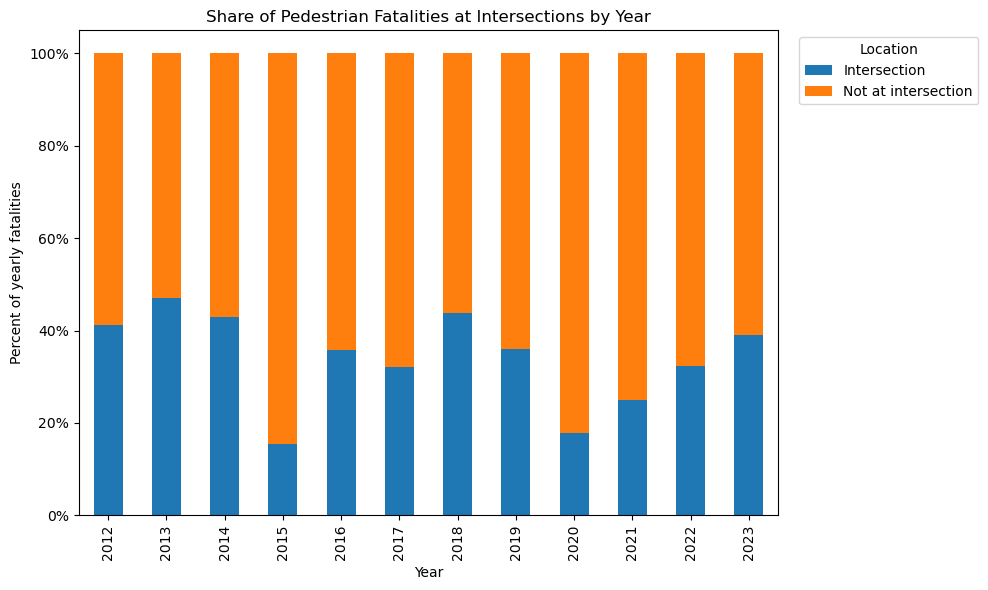

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = ped_fatal_enriched.copy()

# Treat missing as "not at intersection" (change if you prefer an "Unknown" slice)
df["int_cat"] = (df["Intersection"].fillna(0).astype(int)
                   .map({1: "Intersection", 0: "Not at intersection"}))

# Counts per year
pivot = (df.groupby(["Year", "int_cat"])
           .size()
           .unstack(fill_value=0)
           .sort_index())

# Convert to percent of each year's total
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Plot percent stacked bars
ax = pivot_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("Share of Pedestrian Fatalities at Intersections by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Percent of yearly fatalities")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [16]:
ped_fatal_enriched["Interstate"].unique()

array([ 1., nan])

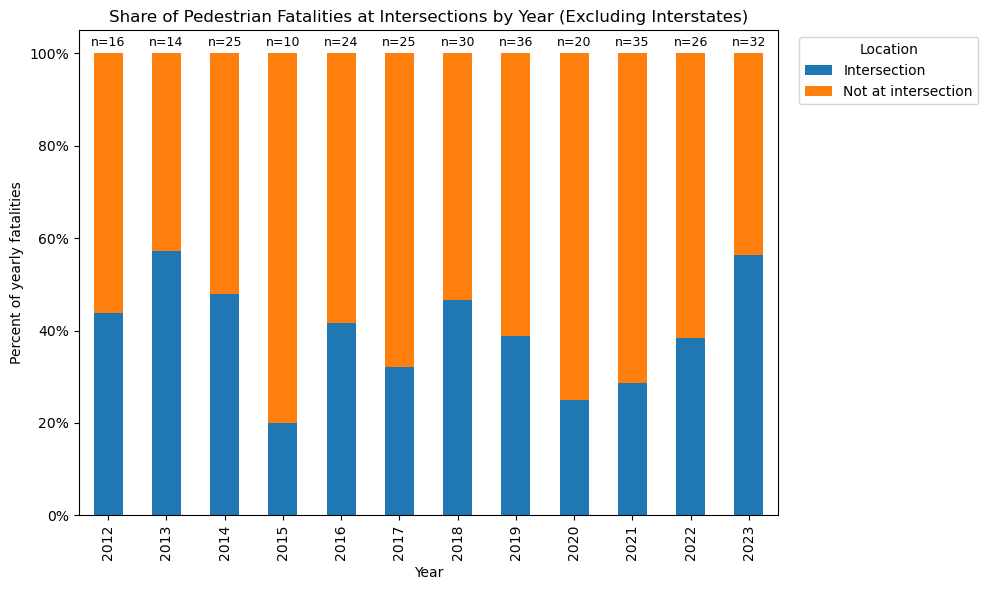

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = ped_fatal_enriched.copy()

# 1) Exclude interstate crashes (keep NaNs and any 0s as "not interstate")
df_no_i = df[df["Interstate"].ne(1)].copy()

# 2) Build intersection category (fold NaNs into "Not at intersection"; change if you prefer "Unknown")
df_no_i["int_cat"] = (
    df_no_i["Intersection"].fillna(0).astype(int)
          .map({1: "Intersection", 0: "Not at intersection"})
)

# 3) Counts per year and % within each year
pivot = (df_no_i.groupby(["Year", "int_cat"])
                 .size()
                 .unstack(fill_value=0)
                 .sort_index())

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 4) Plot: percent stacked bars (excluding interstates)
ax = pivot_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("Share of Pedestrian Fatalities at Intersections by Year (Excluding Interstates)")
ax.set_xlabel("Year")
ax.set_ylabel("Percent of yearly fatalities")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

# Optional: show n for each year above the bars
totals = pivot.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, 101, f"n={int(total)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [22]:
print(pivot)

id_cat  In ID  Outside ID
Year                     
2012        3          14
2013        3          14
2014        7          21
2015        5           8
2016        6          22
2017       11          14
2018        7          25
2019       11          28
2020        6          22
2021       13          27
2022        8          23
2023       13          33


In [18]:
import geopandas as gpd
import fiona

path = "ped_crashes.gpkg"

# See what's inside
layers = fiona.listlayers(path)
print(layers)  # e.g. ['ped_fatal6526', 'ped_injury', 'network_links', ...]

# Load a specific layer by name
ped_fatal_ID = gpd.read_file(path, layer="ped_fatal_6529")
ped_fatal_ID.shape

['ped_all_6529', 'ped_fatal_6529']


(344, 85)

In [19]:
ped_fatal_ID.head()

,UCRnumber,CRASH DATE,Year,MONTH,TIME OF CRASH,HOUR OF CRASH,DAY OF WEEK,LAW ENFORCEMENT AGENCY,COUNTY,CITY,...,ORIGINAL UCR NUMBER,CASE NUMBER,STATION REPORT,TRACS DATA,Interstate,Intersection,Facility,LANES,International_Dist,geometry
0,131931117,7/12/2013,2013,July,17:22,5 p.m.,Friday,Albuquerque Police Department,Bernalillo,Albuquerque,...,None,130062441,No,No,1.0,0,Interstate,3.0,0,POINT (1526944.264 1493776.793)
1,30097966,12/16/2012,2012,December,5:06,5 a.m.,Sunday,Bernalillo County Sheriffs Department,Bernalillo,None,...,None,12682478,No,No,1.0,0,Interstate,3.0,0,POINT (1524368.591 1483834.461)
2,30143912,5/29/2017,2017,May,23:58,11 p.m.,Monday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,9999920,17 - 660913,No,No,NaN,0,4,4.0,0,POINT (1500953.999 1461110.225)
3,30177308,2/9/2016,2016,February,22:19,10 p.m.,Tuesday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,None,16-616310,No,No,1.0,0,Interstate,2.0,0,POINT (1520887.487 1451568.463)
4,30350965,4/9/2023,2023,April,20:18,8 p.m.,Sunday,Bernalillo County Sheriffs Department,Bernalillo,Albuquerque,...,None,SO23040004808,No,No,NaN,0,2,2.0,0,POINT (1500257.647 1479187.887)


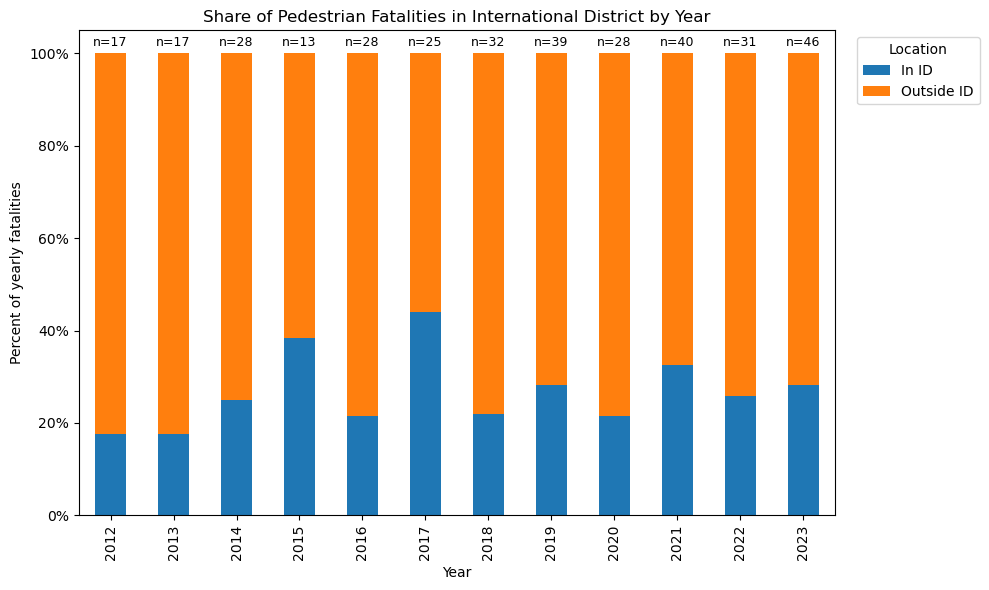

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = ped_fatal_ID.copy()

# Map the binary flag to labels (treat missing as 0 = Outside ID; change to "Unknown" if you prefer)
df["id_cat"] = (
    df["International_Dist"].fillna(0).astype(int)
      .map({1: "In ID", 0: "Outside ID"})
)

# Counts by Year x ID category
pivot = (
    df.groupby(["Year", "id_cat"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

# Convert to percent of each year's total
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Plot percent-stacked bars
ax = pivot_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("Share of Pedestrian Fatalities in International District by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Percent of yearly fatalities")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

# Optional: show n for each year above the bars
totals = pivot.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, 101, f"n={int(total)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


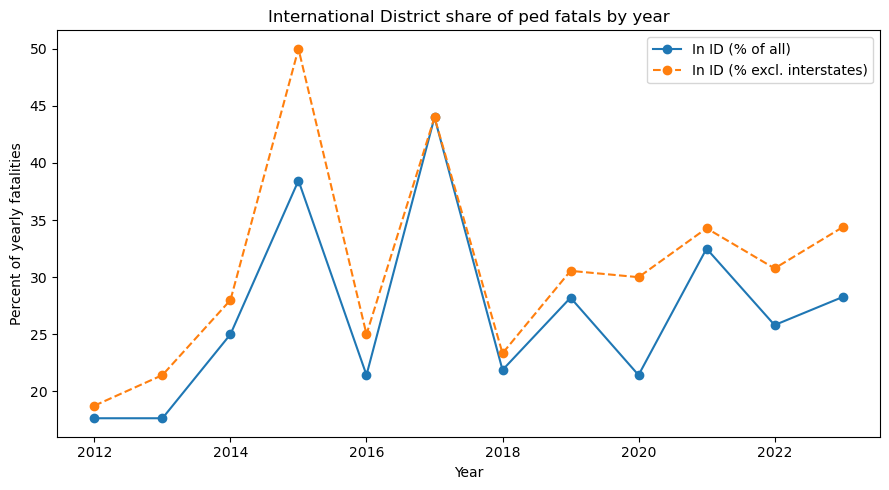

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = ped_fatal_ID.copy()
df["id_flag"] = df["International_Dist"].fillna(0).astype(int)

share_all   = df.groupby("Year")["id_flag"].mean().mul(100)

no_i = df[df["Interstate"].ne(1)].copy()
share_no_i  = no_i.groupby("Year")["id_flag"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(share_all.index, share_all.values, marker="o", label="In ID (% of all)")
ax.plot(share_no_i.index, share_no_i.values, marker="o", linestyle="--",
        label="In ID (% excl. interstates)")
ax.set_title("International District share of ped fatals by year")
ax.set_xlabel("Year")
ax.set_ylabel("Percent of yearly fatalities")
ax.legend()
plt.tight_layout()
plt.show()


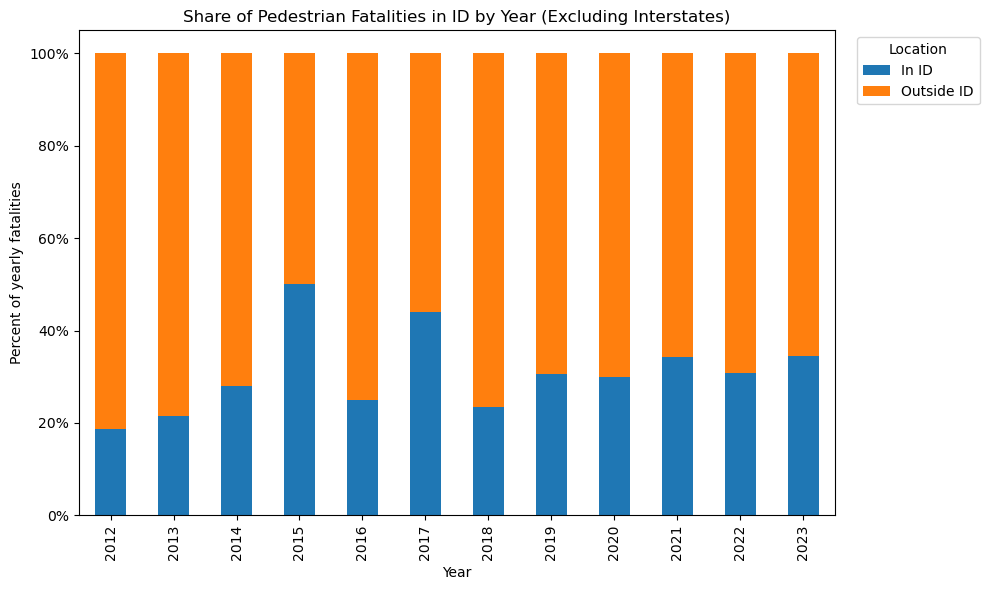

In [24]:
from matplotlib.ticker import PercentFormatter

pivot = (no_i.assign(id_cat=no_i["id_flag"].map({1:"In ID",0:"Outside ID"}))
              .groupby(["Year","id_cat"])
              .size().unstack(fill_value=0).sort_index())

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100)

ax = pivot_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("Share of Pedestrian Fatalities in ID by Year (Excluding Interstates)")
ax.set_xlabel("Year"); ax.set_ylabel("Percent of yearly fatalities")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Location", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


In [26]:
ped_fatal_ID['LIGHTING'].unique()

array(['Daylight', 'Dark-Lighted', 'Dark-Not Lighted', 'Invalid Code',
       'Left Blank', 'Dawn', 'Dusk', 'Dark-Unknown Lighting'],
      dtype=object)

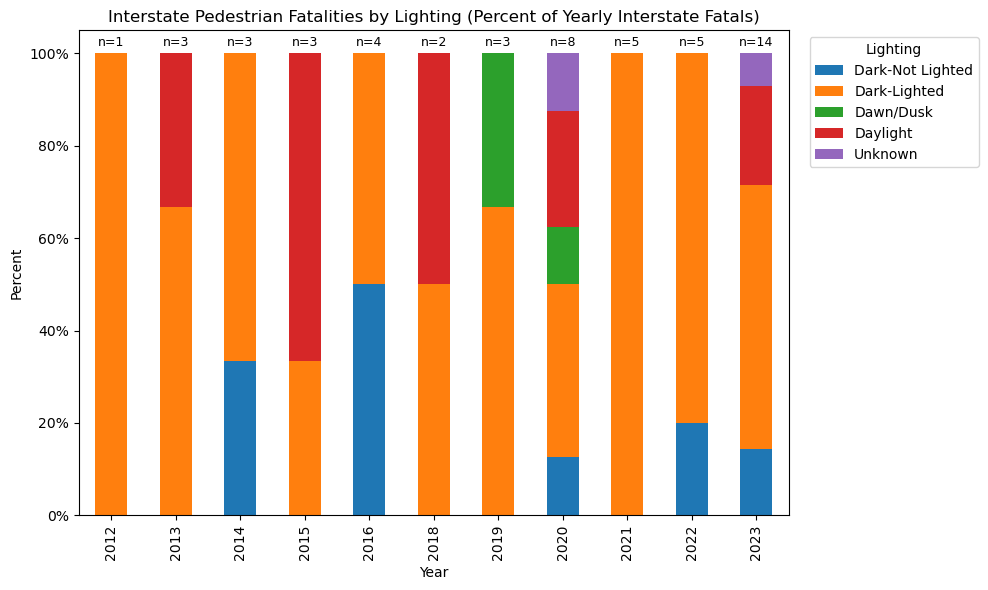

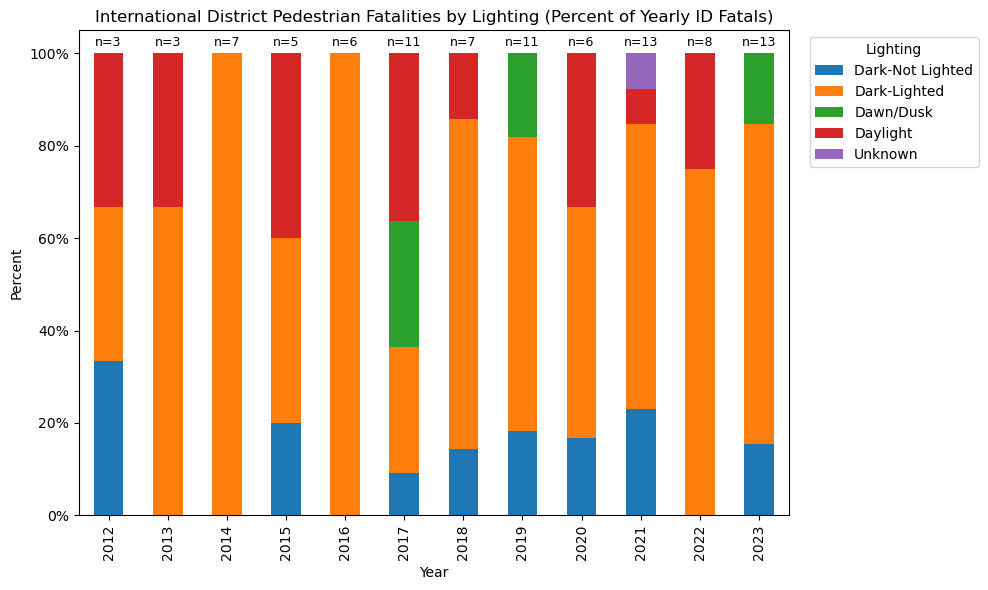

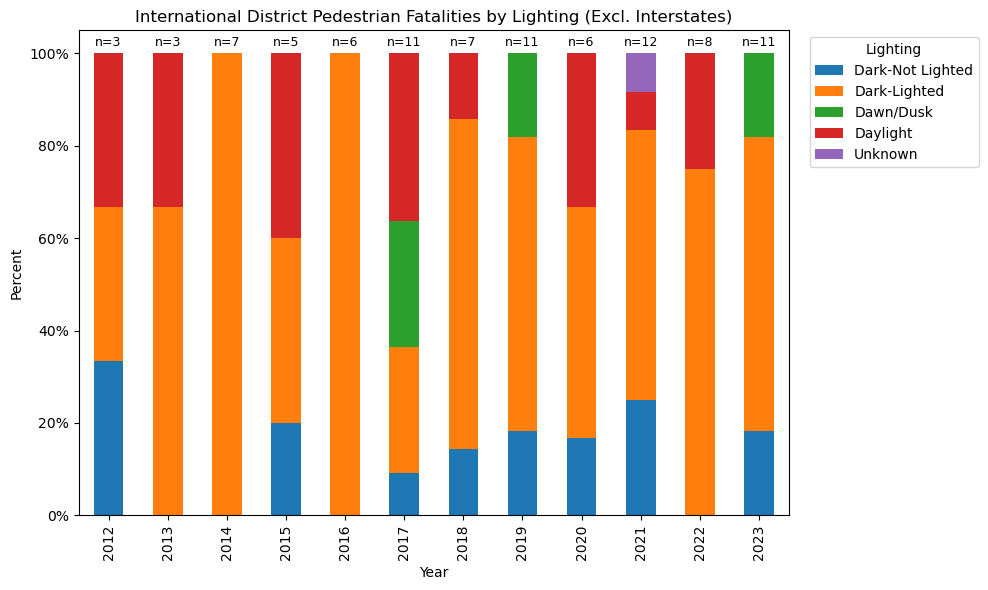

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = ped_fatal_ID.copy()

# --- 1) Normalize lighting categories ---------------------------------------
def norm_light(x):
    if pd.isna(x): return "Unknown"
    s = str(x).strip()
    if s in ("Daylight",): return "Daylight"
    if s in ("Dark-Lighted", "Dark - Lighted", "Dark – Lighted"): return "Dark-Lighted"
    if s in ("Dark-Not Lighted", "Dark - Not Lighted"): return "Dark-Not Lighted"
    if s in ("Dawn", "Dusk"): return "Dawn/Dusk"
    if s in ("Dark-Unknown Lighting", "Invalid Code", "Left Blank"): return "Unknown"
    return s  # fallback

df["light_cat"] = df["LIGHTING"].map(norm_light)

# For consistent legend order (darkest risk to lightest, then unknown)
order = ["Dark-Not Lighted", "Dark-Lighted", "Dawn/Dusk", "Daylight", "Unknown"]

# --- 2) Interstate-only: percent stacked by year -----------------------------
inter = df[df["Interstate"].eq(1)].copy()
pivot_inter = (inter.groupby(["Year","light_cat"])
                    .size().unstack(fill_value=0).sort_index())
pivot_inter = pivot_inter.reindex(columns=[c for c in order if c in pivot_inter.columns])
pivot_inter_pct = pivot_inter.div(pivot_inter.sum(axis=1), axis=0).mul(100)

ax = pivot_inter_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("Interstate Pedestrian Fatalities by Lighting (Percent of Yearly Interstate Fatals)")
ax.set_xlabel("Year"); ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Lighting", bbox_to_anchor=(1.02,1), loc="upper left")

# n labels above bars
n_inter = pivot_inter.sum(axis=1)
for i, n in enumerate(n_inter):
    ax.text(i, 101, f"n={int(n)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

# --- 3) International District: percent stacked by year ----------------------
id_flag = df["International_Dist"].fillna(0).astype(int)
in_id = df[id_flag.eq(1)].copy()

pivot_id = (in_id.groupby(["Year","light_cat"])
                 .size().unstack(fill_value=0).sort_index())
pivot_id = pivot_id.reindex(columns=[c for c in order if c in pivot_id.columns])
pivot_id_pct = pivot_id.div(pivot_id.sum(axis=1), axis=0).mul(100)

ax = pivot_id_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("International District Pedestrian Fatalities by Lighting (Percent of Yearly ID Fatals)")
ax.set_xlabel("Year"); ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Lighting", bbox_to_anchor=(1.02,1), loc="upper left")

n_id = pivot_id.sum(axis=1)
for i, n in enumerate(n_id):
    ax.text(i, 101, f"n={int(n)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

# --- 4) (Optional) ID but EXCLUDING interstates ------------------------------
in_id_no_i = in_id[in_id["Interstate"].ne(1)].copy()
pivot_id_no_i = (in_id_no_i.groupby(["Year","light_cat"])
                        .size().unstack(fill_value=0).sort_index())
pivot_id_no_i = pivot_id_no_i.reindex(columns=[c for c in order if c in pivot_id_no_i.columns])
pivot_id_no_i_pct = pivot_id_no_i.div(pivot_id_no_i.sum(axis=1), axis=0).mul(100)

ax = pivot_id_no_i_pct.plot(kind="bar", stacked=True, figsize=(10,6))
ax.set_title("International District Pedestrian Fatalities by Lighting (Excl. Interstates)")
ax.set_xlabel("Year"); ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title="Lighting", bbox_to_anchor=(1.02,1), loc="upper left")

n_id_no_i = pivot_id_no_i.sum(axis=1)
for i, n in enumerate(n_id_no_i):
    ax.text(i, 101, f"n={int(n)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()


In [31]:
ped_fatal_ID.columns

Index(['UCRnumber', 'CRASH DATE', 'Year', 'MONTH', 'TIME OF CRASH',
       'HOUR OF CRASH', 'DAY OF WEEK', 'LAW ENFORCEMENT AGENCY', 'COUNTY',
       'CITY', 'PRIMARY STREET', 'SECONDARY STREET', 'LANDMARK/LOCATION',
       'GIS-DERIVED ROUTE NAME', 'GIS-DERIVED MILEPOST', 'CRASH DIRECTION',
       'DIRECTION FROM INTERSECTION OR LANDMARK', 'DISTANCE FROM LANDMARK',
       'DISTANCE FROM LANDMARK MEASUREMENT UNIT', 'CRASH SEVERITY',
       'NUMBER OF PEOPLE KILLED IN CRASH',
       'NUMBER OF PEOPLE WITH INCAPACITATING INJURIES (CLASS A) IN CRASH',
       'NUMBER OF PEOPLE WITH VISIBLE INJURIES (CLASS B) IN CRASH',
       'NUMBER OF PEOPLE WITH POSSIBLE INJURIES (CLASS C) IN CRASH',
       'NUMBER OF PEOPLE INJURED (CLASS A+B+C) IN CRASH',
       'NUMBER OF PEOPLE NOT INJURED (CLASS O) IN CRASH',
       'TOTAL NUMBER OF PEOPLE IN CRASH',
       'NUMBER OF VEHICLES, BICYCLES, AND PEDESTRIANS INVOLVED',
       'NUMBER OF PEOPLE IN MOTOR VEHICLES',
       'NUMBER OF PEOPLE NOT IN MOTOR VE

In [36]:
merged.columns

Index(['UCRnumber', 'CRASH DATE', 'MONTH', 'TIME OF CRASH', 'HOUR OF CRASH',
       'DAY OF WEEK', 'CRASH SEVERITY', 'NUMBER OF PEOPLE KILLED IN CRASH',
       'NUMBER OF PEOPLE WITH INCAPACITATING INJURIES (CLASS A) IN CRASH',
       'NUMBER OF PEOPLE WITH VISIBLE INJURIES (CLASS B) IN CRASH',
       'NUMBER OF PEOPLE WITH POSSIBLE INJURIES (CLASS C) IN CRASH',
       'NUMBER OF PEOPLE INJURED (CLASS A+B+C) IN CRASH',
       'NUMBER OF PEOPLE NOT INJURED (CLASS O) IN CRASH',
       'TOTAL NUMBER OF PEOPLE IN CRASH',
       'NUMBER OF VEHICLES, BICYCLES, AND PEDESTRIANS INVOLVED',
       'NUMBER OF PEOPLE IN MOTOR VEHICLES',
       'NUMBER OF PEOPLE NOT IN MOTOR VEHICLES',
       'NUMBER OF MOTOR VEHICLES INVOLVED', 'FIRST HARMFUL EVENT OCCURRED',
       'CRASH CLASSIFICATION', 'CRASH ANALYSIS', 'FIRST HARMFUL EVENT',
       'FIRST HARMFUL EVENT - ANALYSIS', 'FIRST HARMFUL EVENT  LOCATION',
       'FIRST HARMFUL EVENT  MANNER OF IMPACT',
       'FIRST HARMFUL EVENT  MANNER OF CRASH'

In [38]:
# import pandas as pd
# import geopandas as gpd
# from pathlib import Path

# root = Path(".")
# geojson_in  = root / "../ped_fatalities_enriched.geojson"
# geojson_out = root / "ped_fatalities_enriched_v3.geojson"

# key = "UCRnumber"

# # You already have this from earlier:
# # ped_fatal_ID = gpd.read_file("ped_crashes.gpkg", layer="ped_fatal_6529")

# # Load the current GeoJSON you serve to the map
# gj = gpd.read_file(geojson_in)

# # Use the in-memory GDF instead of reading a layer by name
# use_cols = [key, "Interstate", "Intersection", "Facility", "LANES", "International_Dist"]
# attr = ped_fatal_ID[use_cols].copy()
# if "geometry" in attr.columns:
#     attr = attr.drop(columns="geometry")

# # Harmonize key types
# gj[key]   = gj[key].astype(str)
# attr[key] = attr[key].astype(str)

# # Safety: duplicates
# dups = attr[attr.duplicated(key)][key].unique()
# assert len(dups) == 0, f"Duplicate {key} in ped_fatal_ID: {dups[:5]}"

# # Web-friendly copies/buckets
# def bucket_fac(v):
#     if pd.isna(v): return None
#     s = str(v).strip().lower()
#     if s in ("interstate", "intersection"): return s.capitalize()
#     try:
#         n = int(float(s))
#     except ValueError:
#         return None
#     if n >= 6: return "6+ lanes"
#     if n >= 4: return "4-5 lanes"
#     if n >= 2: return "2-3 lanes"
#     return None

# attr_out = pd.DataFrame({
#     key: attr[key],
#     "interstate":   attr["Interstate"].fillna(0).astype(int),
#     "intersection": attr["Intersection"].fillna(0).astype(int),
#     "id_flag":      attr["International_Dist"].fillna(0).astype(int),
#     "lanes":        pd.to_numeric(attr["LANES"], errors="coerce").astype("Int64"),
#     "facility":     attr["Facility"],
#     "facility_group": attr["Facility"].apply(bucket_fac),
# })

# # Merge onto features
# out = gj.merge(attr_out, on=key, how="left", validate="one_to_one")

# # CRS sanity
# if out.crs is None or out.crs.to_epsg() != 4326:
#     out = out.to_crs(4326)

# # Keep only what you need
# keep = [key, "geometry",
#         "RPL_THEMES_max","RPL_THEMES_mean","RPL_THEMES_count",
#         "SVI_ge_0_8","SVI_max","SVI_mean",
#         "interstate","intersection","id_flag","lanes","facility","facility_group"]
# out = out[[c for c in keep if c in out.columns]]

# # Write
# out.to_file(geojson_out, driver="GeoJSON")
# print("Wrote:", geojson_out)
# this one is missing fields we need. going to try again

Wrote: ped_fatalities_enriched_v3.geojson


In [4]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# The notebook's working directory is Analysis/
# So these work with no extra root variable:
geojson_in = "../ped_fatalities_enriched.geojson"  # up one level
gpkg_in    = "ped_crashes.gpkg"                     # same folder
v4_full    = "ped_fatalities_enriched_v4_full.geojson"  # write here
v4_web     = "ped_fatalities_enriched_v4.geojson"

# (Optional) sanity check: show absolute paths + existence
for label, p in [("geojson_in", geojson_in), ("gpkg_in", gpkg_in)]:
    P = Path(p).resolve()
    print(f"{label}: {P}  exists={P.exists()}")

# ... keep the rest of your code unchanged ...

key = "UCRnumber"

# --- Load sources ---
gj = gpd.read_file(geojson_in)
orig = gpd.read_file(gpkg_in, layer=gpkg_layer)

# Harmonize key
gj[key]    = gj[key].astype(str)
orig[key]  = orig[key].astype(str)

# --- Build enrichment (from your earlier code) ---
def bucket_fac(v):
    if pd.isna(v): return None
    s = str(v).strip().lower()
    if s in ("interstate", "intersection"): return s.capitalize()
    try:
        n = int(float(s))
    except ValueError:
        return None
    if n >= 6: return "6+ lanes"
    if n >= 4: return "4-5 lanes"
    if n >= 2: return "2-3 lanes"
    return None

use_cols = [key, "Interstate", "Intersection", "Facility", "LANES", "International_Dist"]
attr = orig[use_cols].copy()
if "geometry" in attr.columns:
    attr = attr.drop(columns="geometry")

attr_out = pd.DataFrame({
    key: attr[key],
    "interstate":   attr["Interstate"].fillna(0).astype(int),
    "intersection": attr["Intersection"].fillna(0).astype(int),
    "id_flag":      attr["International_Dist"].fillna(0).astype(int),
    "lanes":        pd.to_numeric(attr["LANES"], errors="coerce").astype("Int64"),
    "facility":     attr["Facility"],
    "facility_group": attr["Facility"].apply(bucket_fac),
})

# --- Merge enrichment onto the GeoJSON features (which already has SVI fields etc.) ---
out = gj.merge(attr_out, on=key, how="left", validate="one_to_one")

# --- Join back the ORIGINAL attributes you care about (date, severity, lighting, time, etc.) ---
# Keep a generous set now so we don't accidentally drop something useful.
keep_orig = [
    key, "CRASH DATE", "Year", "MONTH", "TIME OF CRASH", "HOUR OF CRASH",
    "DAY OF WEEK", "CRASH SEVERITY", "LIGHTING", "WEATHER", "WEATHER 2",
    "PRIMARY STREET", "SECONDARY STREET", "CITY", "COUNTY",
    "NUMBER OF PEOPLE KILLED IN CRASH",
    "NUMBER OF PEOPLE WITH INCAPACITATING INJURIES (CLASS A) IN CRASH",
    "NUMBER OF PEOPLE WITH VISIBLE INJURIES (CLASS B) IN CRASH",
    "NUMBER OF PEOPLE WITH POSSIBLE INJURIES (CLASS C) IN CRASH",
    "NUMBER OF PEOPLE INJURED (CLASS A+B+C) IN CRASH",
    "TOTAL NUMBER OF PEOPLE IN CRASH",
    "NUMBER OF MOTOR VEHICLES INVOLVED",
    # add any others you anticipate (HIT AND RUN CRASH, ALCOHOL INVOLVEMENT, etc.)
]
orig_keep = orig[[c for c in keep_orig if c in orig.columns]].copy()
out = out.merge(orig_keep.drop(columns=[c for c in ["geometry"] if c in orig_keep.columns]),
                on=key, how="left", validate="one_to_one")

# --- Normalize helper fields for the web app ---
def to_date_iso(s):
    dt = pd.to_datetime(s, errors="coerce")
    return dt.dt.strftime("%Y-%m-%d")

if "CRASH DATE" in out.columns:
    out["date_iso"] = to_date_iso(out["CRASH DATE"])
else:
    out["date_iso"] = pd.NaT

# prefer existing Year if present, else from date
if "Year" in out.columns:
    out["year"] = pd.to_numeric(out["Year"], errors="coerce")
else:
    out["year"] = pd.to_datetime(out["date_iso"], errors="coerce").dt.year

out["month_num"] = pd.to_datetime(out["date_iso"], errors="coerce").dt.month
out["hour"] = pd.to_numeric(out.get("HOUR OF CRASH", pd.NA), errors="coerce")

# Friendly aliases frequently used in UI
out["lighting_norm"] = out.get("LIGHTING")
out["severity"]      = out.get("CRASH SEVERITY")

# --- Ensure CRS WGS84 and write FULL version ---
if out.crs is None or out.crs.to_epsg() != 4326:
    out = out.set_crs(4326, allow_override=True).to_crs(4326)

out.to_file(v4_full, driver="GeoJSON")
print("Wrote FULL:", v4_full, "features:", len(out), "cols:", len(out.columns))

# --- Write a slimmer WEB version (fast to serve) ---
web_cols = [c for c in [
    key, "geometry",
    "date_iso","year","month_num","hour",
    "severity","lighting_norm","LIGHTING","WEATHER","WEATHER 2",
    "facility","facility_group","lanes","interstate","intersection","id_flag",
    # SVI fields already in gj
    "RPL_THEMES_max","RPL_THEMES_mean","RPL_THEMES_count",
    "SVI_ge_0_8","SVI_max","SVI_mean",
    # A few context fields for popups
    "PRIMARY STREET","SECONDARY STREET","CITY","COUNTY",
    "NUMBER OF PEOPLE KILLED IN CRASH",
] if c in out.columns]

out[web_cols].to_file(v4_web, driver="GeoJSON")
print("Wrote WEB: ", v4_web, "features:", len(out), "cols:", len(web_cols))


geojson_in: /Users/willysimon/Documents/Work Stuff/Crash/Ped_Animation/ped_fatalities_enriched.geojson  exists=True
gpkg_in: /Users/willysimon/Documents/Work Stuff/Crash/Ped_Animation/Analysis/ped_crashes.gpkg  exists=True
Wrote FULL: ped_fatalities_enriched_v4_full.geojson features: 343 cols: 87
Wrote WEB:  ped_fatalities_enriched_v4.geojson features: 343 cols: 24
